In [1]:
# IMPORTS AND SETUP
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cf
import easygems.healpix as egh
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set figure parameters
plt.rcParams['figure.dpi'] = 144
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['font.size'] = 10

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [9]:
source = "IMERGv7"
root_dir = "/pscratch/sd/w/wcmca1/hackathon/all_masks/"
# in_dir = f"{root_dir}/ERA5_AR_TC_ETC_hp8_v1.zarr"
in_dir = f"{root_dir}/{source}_allmasks_hp8_v1.zarr"

# Load the processed dataset
print(f"Loading data from: {in_dir}")

ds = xr.open_dataset(in_dir, mask_and_scale=False, engine='zarr')
ds

Loading data from: /pscratch/sd/w/wcmca1/hackathon/all_masks//IMERGv7_allmasks_hp8_v1.zarr


<xarray.Dataset> Size: 30GB
Dimensions:      (time: 1588, cell: 786432)
Coordinates:
  * cell         (cell) int64 6MB 0 1 2 3 4 ... 786428 786429 786430 786431
    crs          int64 8B ...
  * time         (time) datetime64[ns] 13kB 2019-08-01 ... 2020-08-31T18:00:00
Data variables:
    ar_mask      (time, cell) int32 5GB ...
    cloud_types  (time, cell) float32 5GB ...
    etc_mask     (time, cell) int64 10GB ...
    mcs_mask     (time, cell) float32 5GB ...
    tc_mask      (time, cell) int32 5GB ...
Attributes: (12/26)
    CONVERSION_DATE:           Mon Dec  2 16:34:23 MST 2019
    CONVERSION_PLATFORM:       Linux r14i5n18 4.12.14-94.41-default #1 SMP We...
    Contact:                   Zhe Feng: zhe.feng@pnnl.gov
    Conventions:               CF-1.6
    DATA_SOURCE:               ECMWF: https://cds.climate.copernicus.eu, Cope...
    Institution:               Pacific Northwest National Laboratory
    ...                        ...
    processing_script:         combine_era5_imerg_tracking_masks.py
    tb_threshold_coldanvil:    241.0
    tb_threshold_core:         225.0
    tb_threshold_environment:  261.0
    tb_threshold_warmanvil:    261.0
    zoom:                      8

<Figure size 921.6x691.2 with 0 Axes>

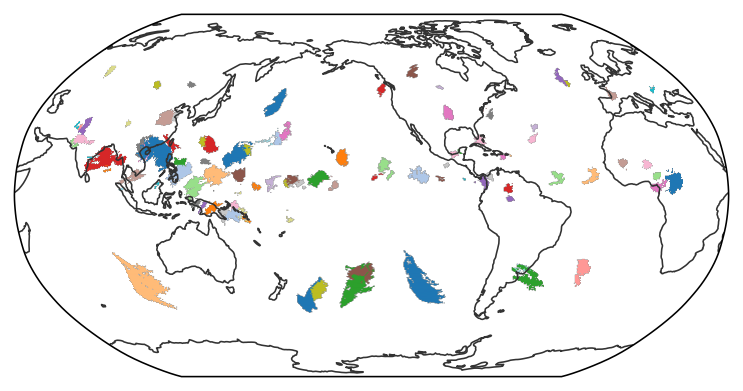

In [3]:
itime = 1
mcs_mask = ds.mcs_mask.isel(time=itime)
egh.healpix_show(mcs_mask.where(mcs_mask > 0), cmap='tab20')

<Figure size 921.6x691.2 with 0 Axes>

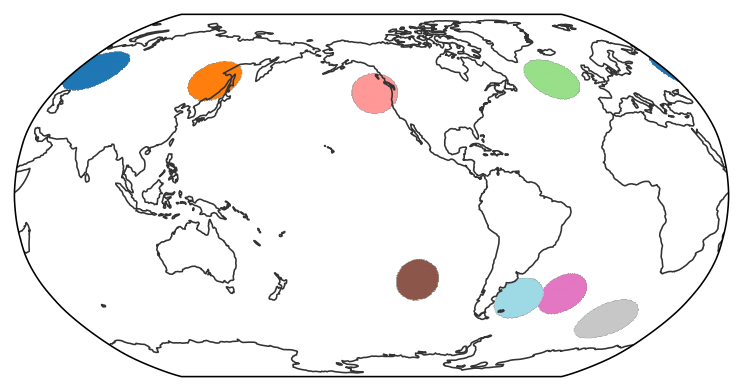

In [4]:
# itime = 1021
itime = 1
etc_mask = ds.etc_mask.isel(time=itime)
egh.healpix_show(etc_mask.where(etc_mask > 0), cmap='tab20')

<Figure size 921.6x691.2 with 0 Axes>

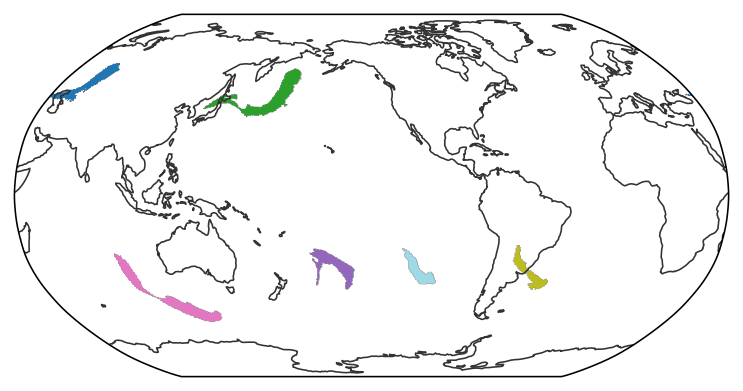

In [5]:
itime = 1
ar_mask = ds.ar_mask.isel(time=itime)
egh.healpix_show(ar_mask.where(ar_mask > 0), cmap='tab20')

<Figure size 921.6x691.2 with 0 Axes>

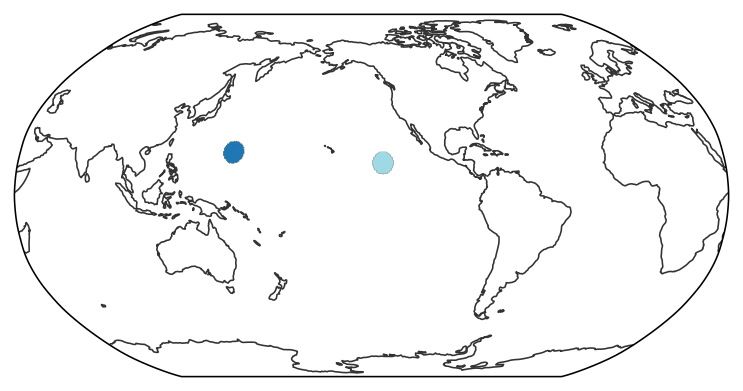

In [6]:
itime = 1
tc_mask = ds.tc_mask.isel(time=itime)
egh.healpix_show(tc_mask.where(tc_mask > 0), cmap='tab20')

In [8]:
ds.cloud_types.attrs

{'comment': 'Classification based on brightness temperature and precipitation rate. Priority for ties: 1>2>3>4.',
 'description': 'Most frequent cloud type within non-MCS cold cloud shield over time window',
 'flag_meanings': 'no_cloud deep_convective stratiform non_deep_convective drizzle',
 'flag_values': [0, 1, 2, 3, 4],
 'grid_mapping': 'crs',
 'long_name': 'Cloud type classification',
 'units': '1',
 'valid_range': [0, 4]}

<Figure size 921.6x691.2 with 0 Axes>

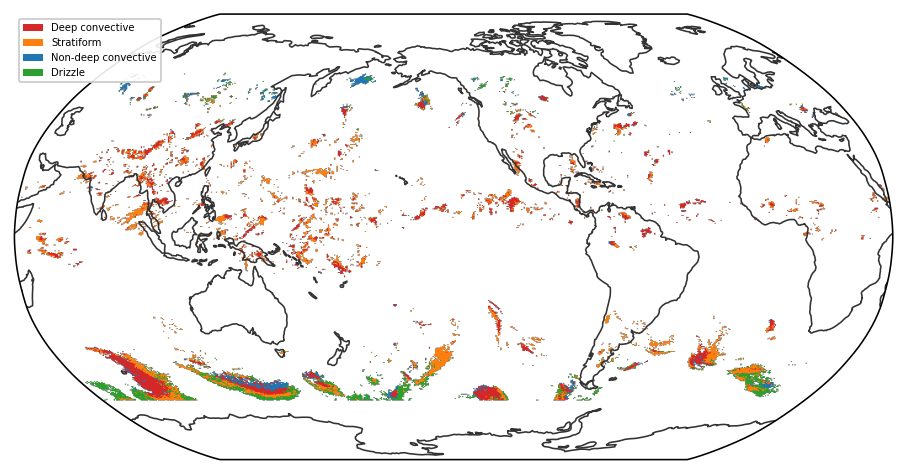

In [10]:
cloud_colors = {
    0: '#ffffff',  # No cloud - white
    1: '#d62728',  # Deep convective - red
    2: '#ff7f0e',  # Stratiform - orange
    3: '#1f77b4',  # Non-deep convective - blue
    4: '#2ca02c',  # Drizzle - green
}
cloud_labels = {
    0: 'No cloud',
    1: 'Deep convective',
    2: 'Stratiform',
    3: 'Non-deep convective',
    4: 'Drizzle'
}
ctype_cmap = mpl.colors.ListedColormap([cloud_colors[i] for i in range(1, 5)])

itime = 1
cloud_types = ds.cloud_types.isel(time=itime)
egh.healpix_show(cloud_types.where(cloud_types > 0), vmin=0.5, vmax=4.5, cmap=ctype_cmap)
# Create custom legend
legend_elements = [Patch(facecolor=cloud_colors[i], label=cloud_labels[i]) 
                   for i in range(1, 5)]
plt.legend(handles=legend_elements, loc='upper left', fontsize=5, framealpha=0.9)
plt.tight_layout()

In [11]:
etc_freq = 100 * (ds.etc_mask > 0).sum(dim='time') / ds.sizes['time']
etc_freq

<xarray.DataArray 'etc_mask' (cell: 786432)> Size: 6MB
array([0., 0., 0., ..., 0., 0., 0.])
Coordinates:
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
    crs      int64 8B ...

<Figure size 921.6x691.2 with 0 Axes>

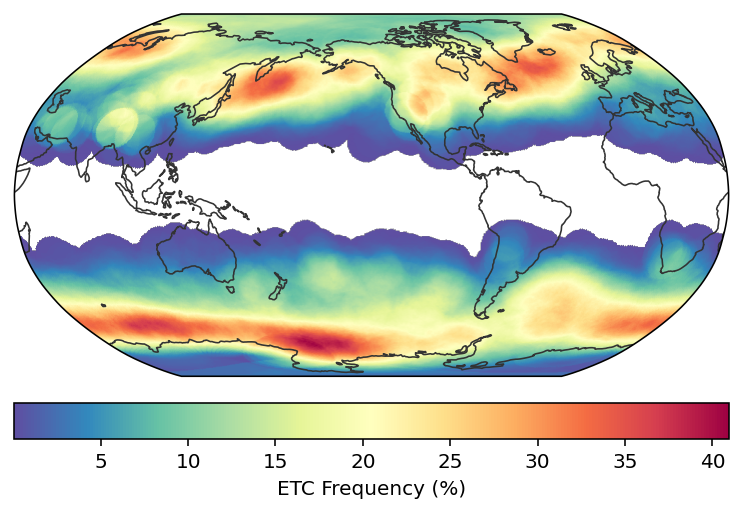

In [12]:
img = egh.healpix_show(etc_freq.where(etc_freq > 0), cmap='Spectral_r')
plt.colorbar(img, orientation='horizontal', label='ETC Frequency (%)', pad=0.05)